In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class Oscillator:
    def __init__(self):
        self.amplitude = 1.0
        self.phase = 0.0
        self.frequency = 2.0
        self.sample_rate = 1000
        self.phase_bl = -0.5
        self.inc = self.frequency / self.sample_rate

    def reset(self):
        self.phase = 0.0
        self.phase_bl = -0.5

    def next_bandlimited_sample(self):
        self.phase_bl += self.inc
        if self.phase_bl >= 1.0:
            self.phase_bl -= 1.0

        output = 0.0
        nyquist = self.sample_rate / 2.0
        h = self.frequency
        i = 1.0
        m = 2.0 / np.pi

        # Adds up sine waves to generate the output waveform
        while h < nyquist:
            output += m * np.sin((np.pi * 2.0 * self.phase_bl * i)) / i
            h += self.frequency
            i += 1.0
            m = -m

        return output

    def next_sample(self):
        return self.amplitude * self.next_bandlimited_sample()

In [3]:
buffer_size = 1000
buffer = np.empty(buffer_size, dtype=np.float32)
osc = Oscillator()
next_sample = osc.next_sample

for i in range(buffer_size):
    buffer[i] = next_sample()

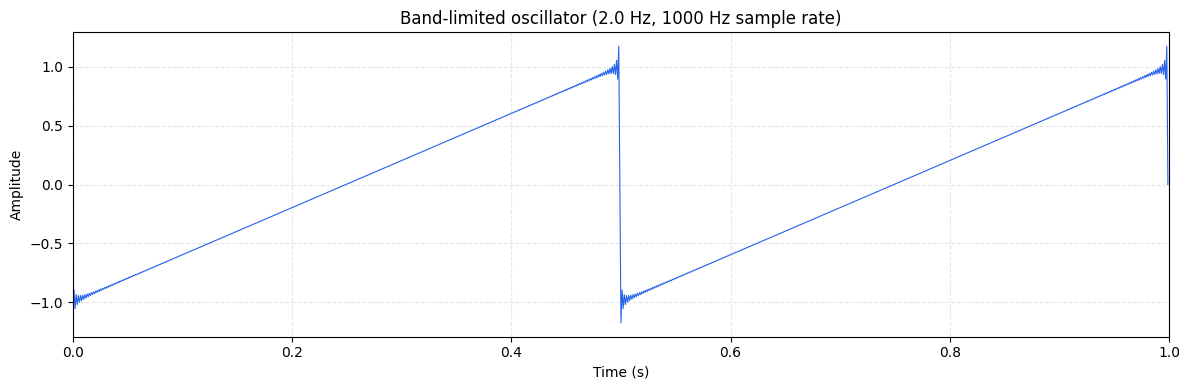

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

t = np.arange(buffer_size) / osc.sample_rate
ax.plot(t, buffer, linewidth=0.8, color="#2563eb")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Band-limited oscillator ({osc.frequency} Hz, {osc.sample_rate} Hz sample rate)")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim(0, buffer_size / osc.sample_rate)

fig.tight_layout()
plt.show()